---   
 <img align="left" width="75" height="75"  src="https://upload.wikimedia.org/wikipedia/en/c/c8/University_of_the_Punjab_logo.png"> 

<h1 align="center">Department of Data Science</h1>
<h1 align="center">Course: Tools and Techniques for Data Science</h1>

---
<h3><div align="right">Instructor: Muhammad Arif Butt, Ph.D.</div></h3>    

<h1 align="center">Lecture 6.23 (Logistic Regression: Part-IV)</h1>

<a href="https://colab.research.google.com/github/arifpucit/data-science/blob/master/Section-4-Mathematics-for-Data-Science/Lec-4.1(Descriptive-Statistics).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <img align="center" width="900" src="images/ml-topimg1.png"  >

# Learning agenda of this notebook

- Theoratical Background for Multinomial Classification
    - Binary vs Multi-Class vs Multi-Label Classification
    - One vs Rest (aka One vs All)
    - Multinomial / Softmax Logistic Regression
- Multi-Class Classification on `iris` Dataset
    - Load Dataset
    - Exploratory Data Analysis
    - Model Training (`ovr` and `multinomial` Logistic Regression)
- Evaluation Metrics for Multi-Class Classification
    - Recap of Confusion Matrix and Evaluation Metrics for Binary Classification
    - Confusion Matrix  for Multi-Class Classifier
    - Accuracy, Precision, Recall and F-1 Scores for Multi-Class Problem
    - `Macro Average` Precision, Recall and F-1 Scores for Multi-Class Problem
    - `Micro Average` Precision, Recall and F-1 Scores for Multi-Class Problem
    - `Weighted Average` Precision, Recall and F-1 Scores for Multi-Class Problem
    
- Evaluate the Logistic Regression Model (`iris dataset`)
- Visualize Decision Boundries for `iris dataset`
- Task To Do (Assignment)

# 1. Theoratical Background for Multinomial Classification

## a. Binary vs Multi-Class vs Multi-Label Classification

<img align="right" width="500" src="images/log34a.png"  > 


- **Binary Classification** is where each data sample is assigned `one and only one label from two mutually exclusive classes`.
    - Email: Spam/Not Spam
    - Online Transaction: Fraudlent (yes/no)
    - Sentiments: Positive/Negative
    - Tumor: Malignant/Benign
    - Algorithms: Logistic Regression, KNN, SVM, Decision Tree, Naive Bayes


- **Multi-class Classification** is where each data sample is assigned `one and only one label from more than two classes.`
    - Sentiments: Positive/Negative/Neutral
    - Emotions: Happy/Sad/Surprised/Angry
    - Fruit Images: Apple/Orange/Banana/Pear
    - Digit Recognition: Zero/One/Two/.../Nine
    - Algorithms: KNN, Decision Trees, Naive Bayes, Random Forest, Gradient Boosting. (Logistic Regression and SVM are designed for binary classification, however, uses one-vs-rest or one-vs-one to implement multi-class classification)


- **Multi-label Classification** is where each data sample can be assigned `zero or more labels`.
    - Genere of a Movie: Romance/History/War
    - Document Clustering: Sports/Politics/Cricket/Economics/Religion
    - Objects in an image: House/Sun/Road/Car/Cat/Dog
    - Algorithms: Scikit-multilearn is a library built on top of scikit-learn that is used for for multi-label classification. Multi-label K Nearest Neighbours, Multi-label Decision Trees, Multi-label Random Forests, Multi-label Gradient Boosting
    - https://pypi.org/project/scikit-multilearn/
    - https://www.section.io/engineering-education/multi-label-classification-with-scikit-multilearn/

>- A multiclass classifier must assign one and only one class or label to each data sample, while a multilabel classifier can assign zero or more classes or labels to the same data sample.

**Logistic Regression's Hyperparameter `multi_class`:**

In [1]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

- The `multi_class` hyperparameter of Logistic Regression model can take three values: `auto`, `ovr`, and `multinomial`, with `auto` as the default value
    - If `multi_class = 'ovr'`, then it will create multiple binary classification models and fit one for each output label
    - If `multi_class = 'multinomial'`, then Sklearn will use a bit different loss function (multinomial loss), and is also known as softmax Logistic Regression.  Can be applied even for binary classification problem. However, remember that `multinomial` is unavailable when `solver = 'liblinear'`
    - If `multi_class = 'auto'`, then 
        - `'ovr'` is used if the data is binary, or if `solver = 'liblinear'`, 
        - otherwise selects `multinomial`

#### Solver Parameters

The solver parameter in logistic regression is used to specify the algorithm that will be used to find the optimal set of coefficients for the model. The five options for the solver parameter are `newton-cg`, `lbfgs`, `liblinear`, `sag`, and `saga`. The choice of solver will depend on the size and characteristics of your dataset, and the desired trade-off between speed and accuracy. `newton-cg`, `lbfgs` and `sag` are more suited for larger datasets, while `liblinear` is more efficient for smaller datasets. `saga` is a solver that combines the benefits of `sag` and `lbfgs` and is generally recommended.

**newton-cg:** The Newton-Conjugate Gradient (Newton-CG) solver is an optimization algorithm used for finding the minimum of a function. It is a combination of Newton's method and the Conjugate Gradient method, and it is particularly well-suited for solving large-scale optimization problems in logistic regression.


**lbfgs:** The Limited-memory Broyden-Fletcher-Goldfarb-Shanno (LBFGS) solver is an optimization algorithm used for finding the minimum of a function. LBFGS is particularly well-suited for problems with a large number of parameters, such as logistic regression, as it can handle a large number of features and still converge quickly. 

**liblinear:** The liblinear solver is an optimization algorithm used for solving linear classification problems, such as logistic regression. It is based on a linear support vector machine (SVM) and is implemented in the C++ library LIBLINEAR.

**saga:** The SAGA (Stochastic Average Gradient Descent) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is an extension of the standard stochastic gradient descent (SGD) algorithm and can handle both L1 and L2 regularization.

**sag:** The Stochastic Average Gradient (SAG) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is a variant of the SAGA algorithm and also uses a mini-batch approach to update the parameters of the model by computing the gradient of the loss function with respect to the parameters using a small random subset of the training data.

**Supported Penalties by Different Solvers are:**
- `lbfgs`     $\hspace{2.5cm}$ -->$\hspace{.5cm}$ ['l2', None]

- `liblinear` $\hspace{1.5cm}$  -->$\hspace{.5cm}$ ['l1', 'l2']

- `newton-cg` $\hspace{1.5cm}$ -->$\hspace{.5cm}$ ['l2', None]

- `newton-cholesky` $\hspace{0.2cm}$ --> $\hspace{.5cm}$['l2', None]

- `sag`    $\hspace{2.8cm}$          --> $\hspace{.5cm}$['l2', None]

- `saga`  $\hspace{2.5cm}$           --> $\hspace{.5cm}$['elasticnet', 'l1', 'l2', None]

## b. One vs Rest (aka One vs All)
<h3 align="center"><div class="alert alert-success" style="margin: 30px">OVR technique use multiple binary classifiers to implement multi-class classification</h3>

<img align="center" width="400" src="images/log35a.png"  > 
<br><br>
<img align="center" width="600" src="images/log35b.png"  > 

<font face = "Courier New" color=green size=5>$$ \text{J(w)} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \biggr[y_i \text{log}(\hat{y}_i)  \hspace{0.3cm}+\hspace{0.3cm} (1 - y_i) \text{log}(1 - \hat{y}_i)\biggr]$$</font>

<img align="center" width="800" src="images/log36a.png"  > 
<img align="center" width="800" src="images/log37a.png"  > 
<img align="center" width="800" src="images/log38a.png"  > 

**Working of OVR:** Multiple binary classifiers to perform a multi-class classification
>- After training is done, we will have a total of nine coefficients or weights (three for each dataset)
>- Given a new input vector, it will be fed to all of the above three models and each model will output a probability value of belonging of the input vector to Green, Blue and Red class
>- The maximum probability value class will be assigned to the new input vector

**Limitation of OVR:** 
>- For `K` classes, we need to train `K` binary classifiers. In above example `K=3`, while it can be a large value

## c. Multinomial / Softmax Logistic Regression
<h3 align="center"><div class="alert alert-success" style="margin: 30px">Multinomial Logistic Regression uses a bit modified Loss Function (cross entropy loss) for training and softmax function instead of sigmoid function</h3>
<img align="center" width="800" src="images/logistic_regression_schematic.png"  > 
    
    
- Logistic Regression gets its name from Logistic/Sigmoid function.
- Logistic Regression for multi-class classification also known as Softmax Regression due to the use of softmax function. It is also called Multinomial Regression
- There are `K` classes and `m` features.
- The model learns `m+1` weights/coefficients for each class.
- Finally there are `K` zee values, which are passed to the softmax function, which convert each zee value to a probability value.
- In softmax regression the softmax function acts as a normalization layer and make sure that the sum of the probabilities of all the classes equals one.

### Loss Function for Multinomial Logistic Regression

<img align="center" width="500" src="images/log40.png"  > 

<font face = "Courier New" color=green size=5>$$ \text{J(w)} \hspace{0.5cm}=\hspace{0.5cm} - \frac{1}{n} \sum_{i=1}^n \sum_{j=1}^K       y^{(i)}_j \text{log}(\hat{y}^{(i)}_j)$$</font>

- Let us expand the above loss function for the dataset having just three rows:<br>
<font face = "Courier New" color=black size=3>$\text{J(w)} \hspace{0.3cm}=\hspace{0.3cm}$
<font face = "Courier New" color=purple size=3>$y^{(1)}_1 log(\hat{y}^{(1)}_1) + y^{(1)}_2 log(\hat{y}^{(1)}_2) + y^{(1)}_3 log(\hat{y}^{(1)}_3) +$
<font face = "Courier New" color=green size=3>$y^{(2)}_1 log(\hat{y}^{(2)}_1) + y^{(2)}_2 log(\hat{y}^{(2)}_2) + y^{(2)}_3 log(\hat{y}^{(2)}_3) +$ 
<font face = "Courier New" color=magenta size=3>$y^{(3)}_1 log(\hat{y}^{(3)}_1) + y^{(3)}_2 log(\hat{y}^{(3)}_2) + y^{(3)}_3 log(\hat{y}^{(3)}_3)
$</font>

<font face = "Courier New" color=black size=3>$\hspace{0.7cm} \text{J(w)} \hspace{0.3cm}=\hspace{0.3cm}$
<font face = "Courier New" color=purple size=3>$y^{(1)}_1 log(\hat{y}^{(1)}_1) \hspace{0.3cm}+\hspace{0.3cm}$
<font face = "Courier New" color=green size=3>$y^{(2)}_2 log(\hat{y}^{(2)}_2) \hspace{0.3cm}+\hspace{0.3cm}$ 
<font face = "Courier New" color=magenta size=3>$ y^{(3)}_3 log(\hat{y}^{(3)}_3)
$</font>

- Now we have $y^{(1)}_1$, $y^{(2)}_2$ and $y^{(3)}_3$ in our dataset, and we have to calculate $\hat{y}^{(1)}_1$, $\hat{y}^{(2)}_2$ and $\hat{y}^{(3)}_3$

<font face = "Courier New" color=black size=3>$\hat{y}^{(1)}_1 \hspace{0.3cm}=\hspace{0.3cm} w^{(1)}_1 x_{11} + w^{(1)}_2 x_{12} + w^{(1)}_0$</font>

<font face = "Courier New" color=black size=3>$\hat{y}^{(2)}_2 \hspace{0.3cm}=\hspace{0.3cm} w^{(2)}_1 x_{21} + w^{(2)}_2 x_{22} + w^{(2)}_0$</font>

<font face = "Courier New" color=black size=3>$\hat{y}^{(3)}_3 \hspace{0.3cm}=\hspace{0.3cm} w^{(3)}_1 x_{31} + w^{(3)}_2 x_{32} + w^{(3)}_0$</font>


- The nine coefficients (weights) can be calculated using Gradient Descent, which will calculate the nine partial derivatives:
<font face = "Courier New" color=black size=3>$$\frac{\partial J}{\partial w^{(1)}_1}, \frac{\partial J}{\partial w^{(1)}_2}, \frac{\partial J}{\partial w^{(1)}_0}\hspace{1cm}           \frac{\partial J}{\partial w^{(2)}_1}, \frac{\partial J}{\partial w^{(2)}_2}, \frac{\partial J}{\partial w^{(2)}_0} \hspace{1cm}          \frac{\partial J}{\partial w^{(3)}_1}, \frac{\partial J}{\partial w^{(3)}_2}, \frac{\partial J}{\partial w^{(3)}_0}
$$</font>

<img align="center" width="1400" src="images/log31b.png"  > 

In [2]:
# softmax() is passed three z values and it maps them to three probabilities whose sum is 1
# The maximum probability specifies that the input vector belong to that class (here second class)
from numpy import exp
def softmax(x):
   return exp(x) / exp(x).sum()

zs = [6.5, 7.2, 5.9]
print(softmax(zs))

[0.28069668 0.56525371 0.15404961]


# 2. Multi-Class Classification on `iris` Dataset
## a. Load Dataset
- The use of multiple measurements in Taxonomic Problems (R.A. Fisher): https://hekyll.services.adelaide.edu.au/dspace/bitstream/2440/15227/1/138.pdf

- Download Dataset: https://archive.ics.uci.edu/ml/datasets/Iris


<img align="center" width="600" src="images/iris.png"  > 
<img align="center" width="200" src="images/petal-sepal.png"  > 

**Datasets that come bundled with Seaborn Library's `load_dataset()` method:**

In [3]:
import seaborn as sns
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


**Load `iris` dataset using Seaborn's `load_dataset('iris')` method:**

In [4]:
df = sns.load_dataset('iris') # Returns a dataframe
df.sample(10, random_state=54)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
45,4.8,3.0,1.4,0.3,setosa
91,6.1,3.0,4.6,1.4,versicolor
103,6.3,2.9,5.6,1.8,virginica
94,5.6,2.7,4.2,1.3,versicolor
96,5.7,2.9,4.2,1.3,versicolor
42,4.4,3.2,1.3,0.2,setosa
79,5.7,2.6,3.5,1.0,versicolor
116,6.5,3.0,5.5,1.8,virginica
4,5.0,3.6,1.4,0.2,setosa


**Load `iris` dataset using Scikit-Learn Library's `load_iris()` method:**

In [6]:
from sklearn import datasets
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

iris = datasets.load_iris() # Returns a Sklearn's bunch object
type(iris)

sklearn.utils.Bunch

In [7]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [8]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [10]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [11]:
# Convert the Sklearn's bunch object to a dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.sample(10, random_state=54)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
45,4.8,3.0,1.4,0.3,0
91,6.1,3.0,4.6,1.4,1
103,6.3,2.9,5.6,1.8,2
94,5.6,2.7,4.2,1.3,1
96,5.7,2.9,4.2,1.3,1
42,4.4,3.2,1.3,0.2,0
79,5.7,2.6,3.5,1.0,1
116,6.5,3.0,5.5,1.8,2
4,5.0,3.6,1.4,0.2,0


In [12]:
df.rename(columns={'sepal length (cm)':'sepal_length', 
                   'sepal width (cm)':'sepal_width', 
                   'petal length (cm)':'petal_length',
                   'petal width (cm)': 'petal_width'}, 
                    inplace=True)
df.sample(10, random_state=54)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
45,4.8,3.0,1.4,0.3,0
91,6.1,3.0,4.6,1.4,1
103,6.3,2.9,5.6,1.8,2
94,5.6,2.7,4.2,1.3,1
96,5.7,2.9,4.2,1.3,1
42,4.4,3.2,1.3,0.2,0
79,5.7,2.6,3.5,1.0,1
116,6.5,3.0,5.5,1.8,2
4,5.0,3.6,1.4,0.2,0


## b. Exploratory Data Analysis (EDA)

Since EDA has no real set methodolgy, the following is a short check list you might want to walk through:

1. What question(s) are you trying to solve (or prove wrong)?
2. What’s missing from the data and how do you deal with it?
3. Are there any outliers and how to treat them?
4. What kind of data do you have and how do you treat different types?
5. How can you add, change or remove features to get more out of your data?
6. How your data is distributed and the correlation between different variables?

In [13]:
# Check out the data types and null values if any 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [14]:
# Check out the different descriptive statistics of numeric columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [15]:
# Checkout the number of observations of each class in dataset
df['species'].value_counts()

0    50
1    50
2    50
Name: species, dtype: int64

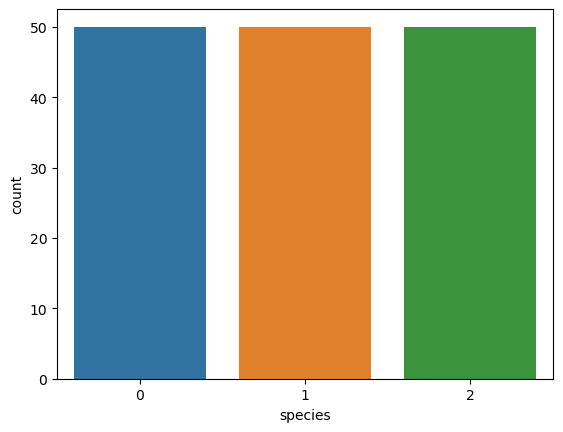

In [16]:
# Visually checkout the number of observations of each class in dataset
sns.countplot(x=df['species']);

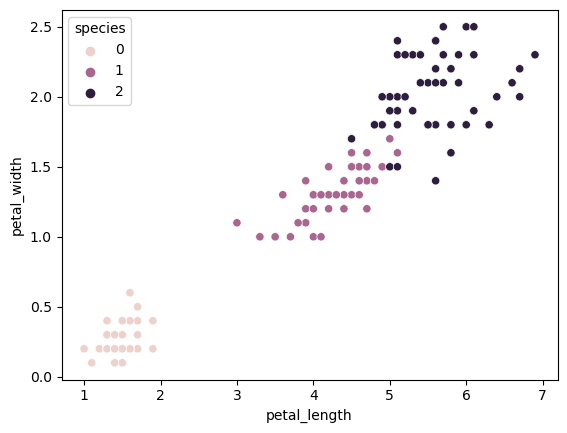

In [17]:
# Visually checkout how separated the data points of the three classes are
sns.scatterplot(x='petal_length', y='petal_width', data=df, hue='species');

>- Note that class 0 (Setosa) is easily or linearly separable from the other two classes i.e., Versicolor and Virginica based on two features  petal_length and petal_width
>- However, Versicolor and Virginica are bit similar and not linearly separable

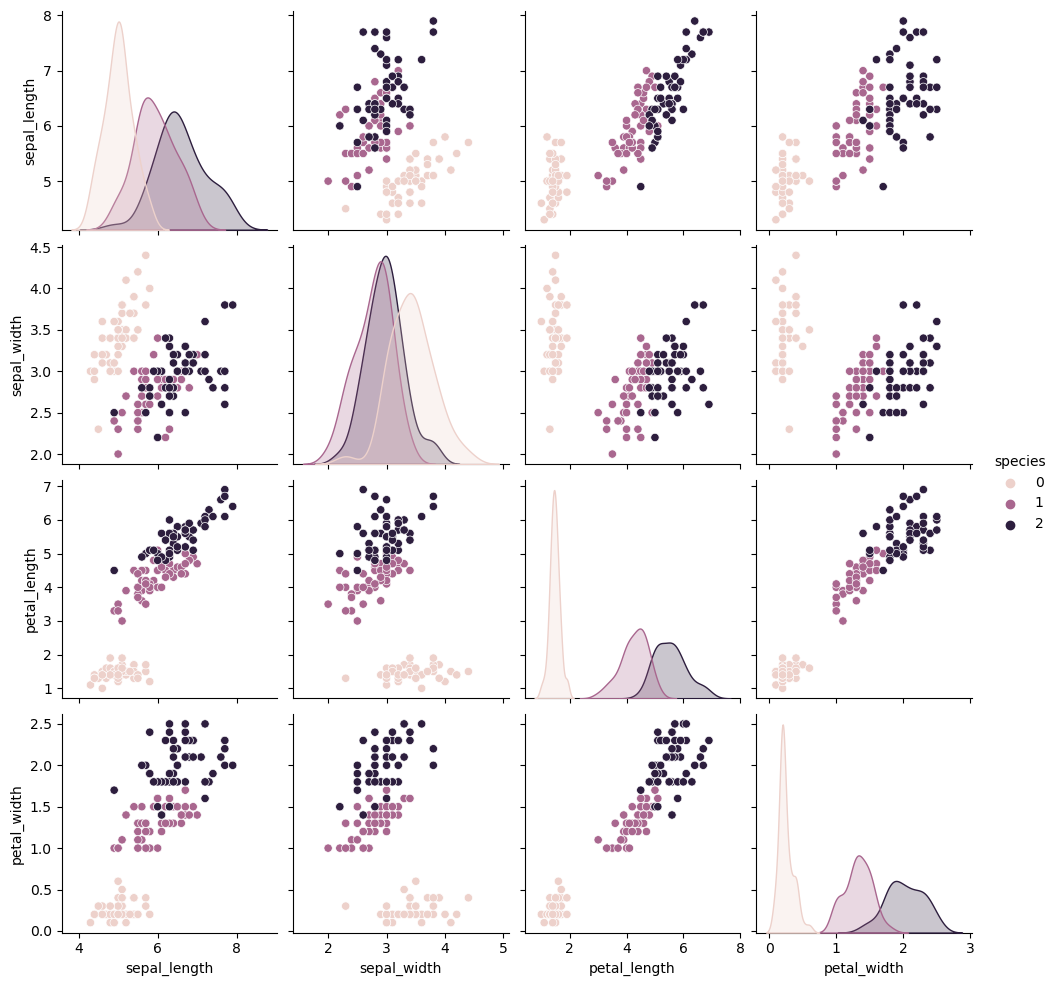

In [18]:
sns.pairplot(df, hue='species');

In [ ]:
sns.heatmap(df.corr(), annot=True);

## c. Model Training (`ovr` and `multinomial` Logistic Regression)
- Since the dataset has 
    - No missing values
    - No outliers
    - No categorical columns
    - All input feature columns has same unit of measurement (centimeter)
- Therefore, we need not to perform any preprocessing on this dataset, and this is all ready to be fed to the machine learning model

In [19]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


**Do a Train-Test Split:**

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop('species', axis=1) # df.iloc[:,0:2]
y = df['species']              # df.iloc[:,-1]

X = df.drop('species', axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
len(X_train), len(y_train), len(X_test), len(y_test)

(120, 120, 30, 30)

**Instentiate and Train the `LogisticRegression()` Model**

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
#model = LogisticRegression(multi_class='ovr', solver='liblinear',penalty='l2', max_iter=5000)
model = LogisticRegression(multi_class='multinomial', solver='sag', penalty='l2', max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000, multi_class='multinomial', solver='sag')

#### Solver Parameters

The solver parameter in logistic regression is used to specify the algorithm that will be used to find the optimal set of coefficients for the model. The five options for the solver parameter are `newton-cg`, `lbfgs`, `liblinear`, `sag`, and `saga`. The choice of solver will depend on the size and characteristics of your dataset, and the desired trade-off between speed and accuracy. `newton-cg`, `lbfgs` and `sag` are more suited for larger datasets, while `liblinear` is more efficient for smaller datasets. `saga` is a solver that combines the benefits of `sag` and `lbfgs` and is generally recommended.

**newton-cg:** The Newton-Conjugate Gradient (Newton-CG) solver is an optimization algorithm used for finding the minimum of a function. It is a combination of Newton's method and the Conjugate Gradient method, and it is particularly well-suited for solving large-scale optimization problems in logistic regression.


**lbfgs:** The Limited-memory Broyden-Fletcher-Goldfarb-Shanno (LBFGS) solver is an optimization algorithm used for finding the minimum of a function. LBFGS is particularly well-suited for problems with a large number of parameters, such as logistic regression, as it can handle a large number of features and still converge quickly. 

**liblinear:** The liblinear solver is an optimization algorithm used for solving linear classification problems, such as logistic regression. It is based on a linear support vector machine (SVM) and is implemented in the C++ library LIBLINEAR.

**saga:** The SAGA (Stochastic Average Gradient Descent) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is an extension of the standard stochastic gradient descent (SGD) algorithm and can handle both L1 and L2 regularization.

**sag:** The Stochastic Average Gradient (SAG) solver is an optimization algorithm used for solving large-scale optimization problems, such as logistic regression. It is a variant of the SAGA algorithm and also uses a mini-batch approach to update the parameters of the model by computing the gradient of the loss function with respect to the parameters using a small random subset of the training data.


**Supported Penalties by Different Solvers are:**
- `lbfgs`     $\hspace{2.5cm}$ -->$\hspace{.5cm}$ ['l2', None]

- `liblinear` $\hspace{1.5cm}$  -->$\hspace{.5cm}$ ['l1', 'l2']

- `newton-cg` $\hspace{1.5cm}$ -->$\hspace{.5cm}$ ['l2', None]

- `newton-cholesky` $\hspace{0.2cm}$ --> $\hspace{.5cm}$['l2', None]

- `sag`    $\hspace{2.8cm}$          --> $\hspace{.5cm}$['l2', None]

- `saga`  $\hspace{2.5cm}$           --> $\hspace{.5cm}$['elasticnet', 'l1', 'l2', None]

**Checkout the Model Coefficients and Intercepts**

In [23]:
# Since there are four i/p features and three output classes, so for each output class we will have four coefficients
print("Model Coefficients:\n",model.coef_)

Model Coefficients:
 [[-0.18124466  0.97376062 -2.28820602 -1.01122713]
 [ 0.45778561 -0.61823339 -0.12351809 -0.86242262]
 [-0.27654095 -0.35552723  2.4117241   1.87364975]]


In [24]:
# For each output class we will have one intercept term
print("Model Intercepts:\n",model.intercept_)

Model Intercepts:
 [  7.54236569   2.86639483 -10.40876052]


**Carry out the Prediction on `X_test`**

In [25]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 2, 1, 1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 1, 2, 2, 0, 0, 1, 2,
       1, 1, 2, 1, 1, 0, 1, 1])

In [26]:
# Check out the Probabilities of each Class
probs = model.predict_proba(X_test)
probs

array([[9.80707642e-01, 1.92922398e-02, 1.18039316e-07],
       [9.64749688e-01, 3.52500020e-02, 3.09925683e-07],
       [8.01602419e-03, 8.07114205e-01, 1.84869771e-01],
       [9.75582994e-05, 1.21017198e-01, 8.78885244e-01],
       [1.85183574e-02, 9.05160777e-01, 7.63208655e-02],
       [2.37950256e-02, 9.01744146e-01, 7.44608280e-02],
       [9.83932456e-01, 1.60674262e-02, 1.17895821e-07],
       [7.18770414e-02, 9.22868244e-01, 5.25471490e-03],
       [1.72241762e-04, 1.66753967e-01, 8.33073792e-01],
       [9.84505695e-01, 1.54942005e-02, 1.04740293e-07],
       [9.85139201e-01, 1.48606997e-02, 9.98381743e-08],
       [3.20936985e-04, 1.55058890e-01, 8.44620173e-01],
       [5.34775089e-04, 3.47301780e-01, 6.52163445e-01],
       [4.88446629e-05, 5.37343414e-02, 9.46216814e-01],
       [3.96809057e-02, 9.50444731e-01, 9.87436303e-03],
       [4.15582664e-03, 9.26040338e-01, 6.98038357e-02],
       [7.47675895e-07, 6.21660011e-03, 9.93782652e-01],
       [1.22905780e-03, 4.60633

>- Let’s create a Dataframe of the above numPy array containing probabilities for better understanding.

In [27]:
df_probs = pd.DataFrame(data=probs, columns=['Setosa', 'Versicolour', 'Virginica'])
df_probs.sample(n=10, random_state=54)

,Setosa,Versicolour,Virginica
10,9.851392e-01,0.014861,9.983817e-08
28,4.987389e-03,0.791954,2.030588e-01
12,5.347751e-04,0.347302,6.521634e-01
16,7.476759e-07,0.006217,9.937827e-01
11,3.209370e-04,0.155059,8.446202e-01
24,8.067273e-05,0.098926,9.009934e-01
27,9.609509e-01,0.039049,3.209977e-07
3,9.755830e-05,0.121017,8.788852e-01
22,5.131116e-03,0.856156,1.387130e-01
18,9.917344e-01,0.008266,4.531231e-08


In [28]:
#The sum of the probabilities must always be 1. We can see here:
df_probs['sum'] = df_probs.sum(axis=1)
df_probs.sample(n=10, random_state=54)

,Setosa,Versicolour,Virginica,sum
10,9.851392e-01,0.014861,9.983817e-08,1.0
28,4.987389e-03,0.791954,2.030588e-01,1.0
12,5.347751e-04,0.347302,6.521634e-01,1.0
16,7.476759e-07,0.006217,9.937827e-01,1.0
11,3.209370e-04,0.155059,8.446202e-01,1.0
24,8.067273e-05,0.098926,9.009934e-01,1.0
27,9.609509e-01,0.039049,3.209977e-07,1.0
3,9.755830e-05,0.121017,8.788852e-01,1.0
22,5.131116e-03,0.856156,1.387130e-01,1.0
18,9.917344e-01,0.008266,4.531231e-08,1.0


In [29]:
y_pred = model.predict(X_test)
df_probs['predicted_class'] = y_pred
df_probs.sample(n=10, random_state=54)

,Setosa,Versicolour,Virginica,sum,predicted_class
10,9.851392e-01,0.014861,9.983817e-08,1.0,0
28,4.987389e-03,0.791954,2.030588e-01,1.0,1
12,5.347751e-04,0.347302,6.521634e-01,1.0,2
16,7.476759e-07,0.006217,9.937827e-01,1.0,2
11,3.209370e-04,0.155059,8.446202e-01,1.0,2
24,8.067273e-05,0.098926,9.009934e-01,1.0,2
27,9.609509e-01,0.039049,3.209977e-07,1.0,0
3,9.755830e-05,0.121017,8.788852e-01,1.0,2
22,5.131116e-03,0.856156,1.387130e-01,1.0,1
18,9.917344e-01,0.008266,4.531231e-08,1.0,0


In [30]:
df_probs['actual_class'] = y_test.to_frame().reset_index().drop(columns='index')
df_probs.sample(n=10, random_state=54)

,Setosa,Versicolour,Virginica,sum,predicted_class,actual_class
10,9.851392e-01,0.014861,9.983817e-08,1.0,0,0
28,4.987389e-03,0.791954,2.030588e-01,1.0,1,1
12,5.347751e-04,0.347302,6.521634e-01,1.0,2,2
16,7.476759e-07,0.006217,9.937827e-01,1.0,2,2
11,3.209370e-04,0.155059,8.446202e-01,1.0,2,2
24,8.067273e-05,0.098926,9.009934e-01,1.0,2,2
27,9.609509e-01,0.039049,3.209977e-07,1.0,0,0
3,9.755830e-05,0.121017,8.788852e-01,1.0,2,2
22,5.131116e-03,0.856156,1.387130e-01,1.0,1,1
18,9.917344e-01,0.008266,4.531231e-08,1.0,0,0


**Evaluate the Model using Accuracy Score**

In [31]:
# Calculate Accuracy score on 20% of the test data
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, y_pred)))

Accuracy: 0.93


**Cross Validation using `cross_val_score()`:**

In [32]:
# Calculate Accuracy score on entire dataset using cross_val_score() method
from sklearn.model_selection import cross_val_score

scores_array = cross_val_score(model, X, y, cv=5, scoring='accuracy')
scores_array

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])

In [33]:
print("Accuracy: %0.2f (+/- %0.2f)" % (scores_array.mean(), scores_array.std() * 2))

Accuracy: 0.97 (+/- 0.05)


# 3. Evaluation Metrics for Multi-Class Classification

## a. Recap of Confusion Matrix and Evaluation Metrics for Binary Classification

<img align="center" width="850"  src="images/log26.png"  > 

## b. Confusion Matrix  for Multi-Class Classifier

In [1]:
# A hypothetical model result having 30 actual and 30 predicted y values
import numpy as np
from sklearn.metrics import confusion_matrix

y_actual = np.array([0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,2,0,1,1,0,0,0,0,2,2,2,1,1,2])
y_predicted = np.array([1,0,0,1,0,0,1,2,1,0,0,0,0,0,2,1,1,1,1,0,0,0,1,0,0,0,0,2,2,2])
print("Actual label:    ", y_actual )
print("Predicted label: ", y_predicted)
confusion_matrix(y_actual,y_predicted)

Actual label:     [0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 2 0 1 1 0 0 0 0 2 2 2 1 1 2]
Predicted label:  [1 0 0 1 0 0 1 2 1 0 0 0 0 0 2 1 1 1 1 0 0 0 1 0 0 0 0 2 2 2]


array([[11,  5,  2],
       [ 2,  3,  2],
       [ 3,  1,  1]])

<img align="center" width="700"  src="images/log42a.png"  > 

### Constructing Confusion Matrix for Class A
<img align="center" width="800"  src="images/log43.png"  > 

- **TP:** the True-positive value is where the actual value and predicted value are the same.
- **FP:** The False-positive value for a class will be the sum of values of the corresponding `column` except for the TP value. 
- **FN:** The False-negative value for a class will be the sum of values of the corresponding `row` except for the TP value. 
- **TN:** The True-negative value for a class will be the sum of values of all columns and rows except the values of that class that we are calculating the values for. 

<br><br>

### Constructing Confusion Matrix for Class B
<img align="center" width="800"  src="images/log44.png"  > 
<br><br>

### Constructing Confusion Matrix for Class C
<img align="center" width="800"  src="images/log45.png"  > 

## c. Accuracy, Precision, Recall and F-1 Scores for Multi-Class Problem

<img align="center" width="850"  src="images/log41.png"  > 

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_actual, y_predicted)
precision = precision_score(y_actual, y_predicted, average=None)
recall = recall_score(y_actual, y_predicted, average=None)
f1 = f1_score(y_actual, y_predicted, average=None)

print("Accuracy score: ", accuracy)
print("Precision score: ", precision)
print("Recall score: ", recall)
print("F1 score: ", f1)
print("\n Classification Report:\n", classification_report(y_actual, y_predicted))

Accuracy score:  0.5
Precision score:  [0.6875     0.33333333 0.2       ]
Recall score:  [0.61111111 0.42857143 0.2       ]
F1 score:  [0.64705882 0.375      0.2       ]

 Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30



## d. `Macro Average` Precision, Recall and F-1 Scores for Multi-Class Problem

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">We use <b>macro averaging</b> when we want to give an equal weight to each class. If you are working with an <b>imbalanced dataset</b> where all classes are equally important, macro average is a good choice as it treats all classes equally.</font></center>

    
<img align="right" width="470"  src="images/log41.png"  > 

**Macro Average Precision** is the arithmetic mean of `Precision` of all classes<br><br>
$ = \large \frac{Precision_A+Precision_B+Precision_C}{3}=\frac{0.6875+0.333+0.2}{3} =  \small 0.4069$
<br><br><br><br>
**Macro Average Recall** is the arithmetic mean of `Recall` of all classes<br><br>
$ = \large \frac{Recall_A+Recall_B+Recall_C}{3}=\frac{0.611+0.428+0.2}{3}= \small 0.413$
<br><br><br><br>
**Macro Average F1** is the arithmetic mean of `F1` of all classes<br><br>
$ =  \large \frac{F1_A+F1_B+F1_C}{3}=\frac{0.647+0.375+0.2}{3}=\small 0.407$

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

macro_precision = precision_score(y_actual, y_predicted, average='macro')
macro_recall = recall_score(y_actual, y_predicted, average='macro')
macro_f1 = f1_score(y_actual, y_predicted, average='macro')

print("Macro Precision score: ", macro_precision)
print("Macro Recall score: ", macro_recall)
print("Macro F1 score: ", macro_f1)
print("\n Classification Report:\n", classification_report(y_actual, y_predicted))

Macro Precision score:  0.4069444444444444
Macro Recall score:  0.4132275132275132
Macro F1 score:  0.40735294117647053

 Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30



## e. `Micro Average` Precision, Recall and F-1 Scores for Multi-Class Problem

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">We use <b>micro averaging</b> when we want to give an equal weight to each instance or prediction.</font></center>


<img align="right" width="475"  src="images/log42a.png"  > 

**Micro Average Precision:** is the sum of all TPs divided by the sum of all TPs plus the sum of all FPs.<br><br>
$ = \large \frac{TP_A+TP_B+TP_C}{(TP_A+TP_B+TP_C) + (FP_A+FP_B+FP_C)}=\frac{11+3+1}{(11+3+1) + (5+6+4)} =  \small 0.5$
<br><br>

**Micro Average Recall:**  is the sum of all TPs divided by the sum of all TPs plus the sum of all FNs.<br><br>
$ = \large \frac{TP_A+TP_B+TP_C}{(TP_A+TP_B+TP_C)+(FN_A+FN_B+FN_C)}=\frac{11+3+1}{(11+3+1)+(7+4+4)} =  \small 0.5$
<br><br>

**Micro Average F1:** <br><br>
$ F1 =  \large \frac{2PR}{P+R}$<br><br>
$ F1 = \large \frac{TP}{TP+0.5\times (FP+FN)}= \large \frac{TP_A+TP_B+TP_C}{TP_A+TP_B+TP_C +0.5 \times (FP_A+FP_B+FP_C+FN_A+FN_B+FN_C)}=\frac{11+3+1}{11+3+1+0.5(5+6+4+7+4+4)} =  \small 0.5$

<br><br>
>- **TP:** is the sum of values of the diagonal, where the actual value and predicted value are the same.($TP_A=11, TP_B=3, TP_C=1$)
>- **FP:** is the sum of values of corresponding column except for the TP value. ($FP_A=5, FP_B=6, FP_C=4$)
>- **FN:** is the sum of values of corresponding row except for the TP value. ($FN_A=7, FN_B=4, FN_C=4$)
>- **TN:** is the sum of values of all columns and rows except the values of the class that we are calculating the TN for. $(TN_A=7, TN_B=17, TN_C=21)$

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

micro_precision = precision_score(y_actual, y_predicted, average='micro')
micro_recall = recall_score(y_actual, y_predicted, average='micro')
micro_f1 = f1_score(y_actual, y_predicted, average='micro')

print("Micro Precision score: ", micro_precision)
print("Micro Recall score: ", micro_recall)
print("Micro F1 score: ", micro_f1)
print("\n Classification Report:\n", classification_report(y_actual, y_predicted))

Micro Precision score:  0.5
Micro Recall score:  0.5
Micro F1 score:  0.5

 Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30



<center><font face = "Garamond" color=blue size=5>The difference between <em>macro</em> and <em>micro</em> averaging is that <b>macro weighs each class equally</b> whereas <b>micro weighs each sample equally</b>. If you have an equal number of samples for each class, then macro and micro will result in the same score.</font></center>


## f. `Weighted Average` Precision, Recall and F-1 Scores for Multi-Class Problem

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">We use <b>weighted averaging</b>, while working with <b>imbalanced datasets</b>, when we want to assign greater contribution to classes with more number of samples in the dataset.</font></center>


<img align="right" width="470"  src="images/log41.png"  > 

**Weighted Average Precision** is the average of the actual instances of classes times the `Precision` of the classes<br><br>
$ = \large \frac{18*0.6875+7*0.333+5*0.2}{18+7+5} =  \small 0.523$
<br><br><br><br>
**Weighted Average Recall** is the average of the actual instances of classes times the `Recall` of the classes<br><br>
$ = \large \frac{18*0.611+7*0.428+5*0.2}{18+7+5} =  \small 0.5$
<br><br><br><br>
**Weighted Average F1** is the average of the actual instances of classes times the `Recall` of the classes<br><br>
$ = \large \frac{18*0.647+7*0.375+5*0.2}{18+7+5} =  \small 0.509$

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

weighted_precision = precision_score(y_actual, y_predicted, average='weighted')
weighted_recall = recall_score(y_actual, y_predicted, average='weighted')
weighted_f1 = f1_score(y_actual, y_predicted, average='weighted')

print("Weighted Precision score: ", weighted_precision)
print("Weighted Recall score: ", weighted_recall)
print("Weighted F1 score: ", weighted_f1)
print(classification_report(y_actual, y_predicted))

Weighted Precision score:  0.523611111111111
Weighted Recall score:  0.5
Weighted F1 score:  0.5090686274509805
              precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30



## g. Other Metrics

**Cohen’s Kappa:** 
- Cohen's Kappa is a measure of agreement between two dependent categorical samples, and you use it whenever you want to know if two raters' measurements are in agreement.
- This is one of the best metrics for evaluating multi-class classifiers on imbalanced datasets. The traditional metrics from the classification report are biased towards the majority class and assumes an identical distribution of the actual and predicted classes. In contrast, Cohen’s Kappa Statistic measures the proximity of the predicted classes to the actual classes when compared to a random classification. The output is normalized between 0 and 1 the metrics for each classifier, therefore can be directly compared across the classification task. Generally closer the score is to one, better the classifier.
- If you have a `nominal variable` and you want to know how much agreement there is between two raters, you would use `Cohen's Kappa`. If you have an `ordinal variable` and two raters, you would use `Kendall's tau` or the `weighted Cohen's Kappa`, and if you have a `metric variable`, you would use `Pearson's correlation`. If you have more than two nominal dependent samples, the `Fleiss Kappa` is used.

**Mathews Correlation Coefficient (MCC):** MCC, originally devised for binary classification on unbalanced classes, has been extended to evaluates multiclass classifiers by computing the correlation coefficient between the observed and predicted classifications. A coefficient of +1 represents a perfect prediction, 0 is similar to a random prediction and −1 indicates an inverse prediction.

# 4. Evaluate the Logistic Regression Model (`iris dataset`)

## a. Confusion Matrix

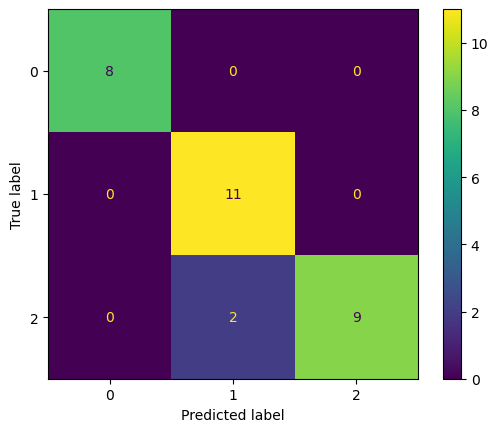

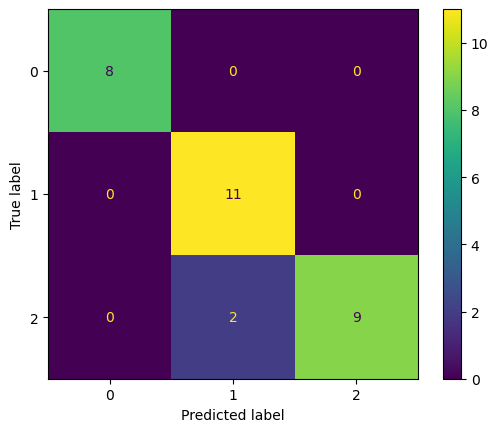

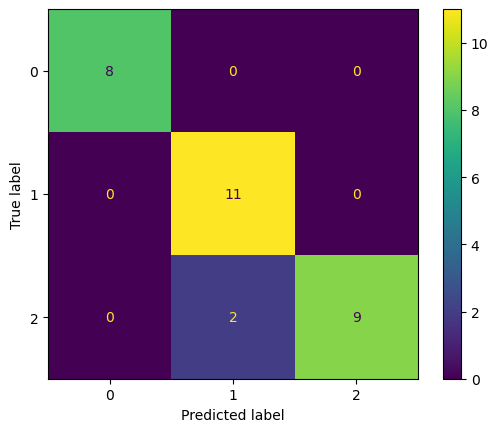

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot();

ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

## b. `Macro Average` Precision, Recall and F-1 Scores

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("Macro Precision score: ", macro_precision)
print("Macro Recall score: ", macro_recall)
print("Macro F1 score: ", macro_f1)

Macro Precision score:  0.9487179487179488
Macro Recall score:  0.9393939393939394
Macro F1 score:  0.9388888888888888


## c. `Micro Average` Precision, Recall and F-1 Scores

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

micro_precision = precision_score(y_test, y_pred, average='micro')
micro_recall = recall_score(y_test, y_pred, average='micro')
micro_f1 = f1_score(y_test, y_pred, average='micro')

print("Micro Precision score: ", micro_precision)
print("Micro Recall score: ", micro_recall)
print("Micro F1 score: ", micro_f1)

Micro Precision score:  0.9333333333333333
Micro Recall score:  0.9333333333333333
Micro F1 score:  0.9333333333333333


## d. `Weighted Average` Precision, Recall and F-1 Scores

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

weighted_precision = precision_score(y_test, y_pred, average='weighted')
weighted_recall = recall_score(y_test, y_pred, average='weighted')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print("Weighted Precision score: ", weighted_precision)
print("Weighted Recall score: ", weighted_recall)
print("Weighted F1 score: ", weighted_f1)
print(classification_report(y_test, y_pred))

Weighted Precision score:  0.9435897435897436
Weighted Recall score:  0.9333333333333333
Weighted F1 score:  0.9327777777777778
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.85      1.00      0.92        11
           2       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.95      0.94      0.94        30
weighted avg       0.94      0.93      0.93        30



## e. Visualize Decision Boundries

In [43]:
# Dataset has four input features, which is a bit difficult to plot/visualize with the two hyperplanes
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [44]:
# Let us use two input features only and train and test the model for easy visualization of decision bdry
df = df[['sepal_length','petal_length','species']]
df

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2


In [45]:
X = df.drop('species', axis=1) # df.iloc[:,0:2]
y = df['species']              # df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
model = LogisticRegression(solver='saga', multi_class='ovr', max_iter=5000, C=12.9155, penalty='l1')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# https://rasbt.github.io/mlxtend/
#import sys
#!{sys.executable} -m pip install mlxtend --upgrade --no-deps

/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


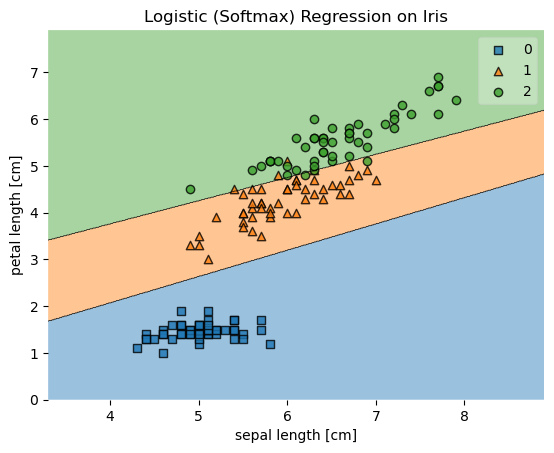

In [46]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X=X.values, y=y.values, clf=model)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.title('Logistic (Softmax) Regression on Iris')
plt.show();

# Task To Do
# 1. Digit Classification:
#### Toy Datasets of Scikit-Learn Library: https://scikit-learn.org/stable/datasets/toy_dataset.html

<img src="images/pca_digits.png" style="width: 900px;"/>

# 2. MNIST - 6K Handwritten Digits):
#### Download Dataset: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
<img src="images/mnist1.png" style="width: 1200px;"/>

In [ ]:
import pandas as pd
df = pd.read_csv('datasets/disease-quiz.csv')
df

In [9]:
# A hypothetical model result having 30 actual and 30 predicted y values
import numpy as np
from sklearn.metrics import confusion_matrix

y_actual = np.array   ([0, 1, 0, 0, 0, 1, 0, 2, 1, 1, 2, 1])
y_predicted = np.array([1, 0, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1])
print("Actual label:    ", y_actual )
print("Predicted label: ", y_predicted)
confusion_matrix(y_actual,y_predicted)

Actual label:     [0 1 0 0 0 1 0 2 1 1 2 1]
Predicted label:  [1 0 2 0 0 0 1 2 1 1 2 1]


array([[2, 2, 1],
       [2, 3, 0],
       [0, 0, 2]])

<img align="center" width="700"  src="images/log42a.png"  > 

### Constructing Confusion Matrix for Class A
<img align="center" width="800"  src="images/log43.png"  > 

- **TP:** the True-positive value is where the actual value and predicted value are the same.
- **FP:** The False-positive value for a class will be the sum of values of the corresponding `column` except for the TP value. 
- **FN:** The False-negative value for a class will be the sum of values of the corresponding `row` except for the TP value. 
- **TN:** The True-negative value for a class will be the sum of values of all columns and rows except the values of that class that we are calculating the values for. 

<br><br>

### Constructing Confusion Matrix for Class B
<img align="center" width="800"  src="images/log44.png"  > 
<br><br>

### Constructing Confusion Matrix for Class C
<img align="center" width="800"  src="images/log45.png"  > 

## c. Accuracy, Precision, Recall and F-1 Scores for Multi-Class Problem

<img align="center" width="850"  src="images/log41.png"  > 

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_actual, y_predicted)
precision = precision_score(y_actual, y_predicted, average=None)
recall = recall_score(y_actual, y_predicted, average=None)
f1 = f1_score(y_actual, y_predicted, average=None)

print("Accuracy score: ", accuracy)
print("Precision score: ", precision)
print("Recall score: ", recall)
print("F1 score: ", f1)
print("\n Classification Report:\n", classification_report(y_actual, y_predicted))

Accuracy score:  0.4
Precision score:  [0.33333333 0.5        0.33333333]
Recall score:  [0.33333333 0.5        0.33333333]
F1 score:  [0.33333333 0.5        0.33333333]

 Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.50      0.50      0.50         4
           2       0.33      0.33      0.33         3

    accuracy                           0.40        10
   macro avg       0.39      0.39      0.39        10
weighted avg       0.40      0.40      0.40        10



## d. `Macro Average` Precision, Recall and F-1 Scores for Multi-Class Problem

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">We use <b>macro averaging</b> when we want to give an equal weight to each class. If you are working with an <b>imbalanced dataset</b> where all classes are equally important, macro average is a good choice as it treats all classes equally.</font></center>

    
<img align="right" width="470"  src="images/log41.png"  > 

**Macro Average Precision** is the arithmetic mean of `Precision` of all classes<br><br>
$ = \large \frac{Precision_A+Precision_B+Precision_C}{3}=\frac{0.6875+0.333+0.2}{3} =  \small 0.4069$
<br><br><br><br>
**Macro Average Recall** is the arithmetic mean of `Recall` of all classes<br><br>
$ = \large \frac{Recall_A+Recall_B+Recall_C}{3}=\frac{0.611+0.428+0.2}{3}= \small 0.413$
<br><br><br><br>
**Macro Average F1** is the arithmetic mean of `F1` of all classes<br><br>
$ =  \large \frac{F1_A+F1_B+F1_C}{3}=\frac{0.647+0.375+0.2}{3}=\small 0.407$

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

macro_precision = precision_score(y_actual, y_predicted, average='macro')
macro_recall = recall_score(y_actual, y_predicted, average='macro')
macro_f1 = f1_score(y_actual, y_predicted, average='macro')

print("Macro Precision score: ", macro_precision)
print("Macro Recall score: ", macro_recall)
print("Macro F1 score: ", macro_f1)
print("\n Classification Report:\n", classification_report(y_actual, y_predicted))

Macro Precision score:  0.4069444444444444
Macro Recall score:  0.4132275132275132
Macro F1 score:  0.40735294117647053

 Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30



## e. `Micro Average` Precision, Recall and F-1 Scores for Multi-Class Problem

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">We use <b>micro averaging</b> when we want to give an equal weight to each instance or prediction.</font></center>


<img align="right" width="475"  src="images/log42a.png"  > 

**Micro Average Precision:** is the sum of all TPs divided by the sum of all TPs plus the sum of all FPs.<br><br>
$ = \large \frac{TP_A+TP_B+TP_C}{(TP_A+TP_B+TP_C) + (FP_A+FP_B+FP_C)}=\frac{11+3+1}{(11+3+1) + (5+6+4)} =  \small 0.5$
<br><br>

**Micro Average Recall:**  is the sum of all TPs divided by the sum of all TPs plus the sum of all FNs.<br><br>
$ = \large \frac{TP_A+TP_B+TP_C}{(TP_A+TP_B+TP_C)+(FN_A+FN_B+FN_C)}=\frac{11+3+1}{(11+3+1)+(7+4+4)} =  \small 0.5$
<br><br>

**Micro Average F1:** <br><br>
$ F1 =  \large \frac{2PR}{P+R}$<br><br>
$ F1 = \large \frac{TP}{TP+0.5\times (FP+FN)}= \large \frac{TP_A+TP_B+TP_C}{TP_A+TP_B+TP_C +0.5 \times (FP_A+FP_B+FP_C+FN_A+FN_B+FN_C)}=\frac{11+3+1}{11+3+1+0.5(5+6+4+7+4+4)} =  \small 0.5$

<br><br>
>- **TP:** is the sum of values of the diagonal, where the actual value and predicted value are the same.($TP_A=11, TP_B=3, TP_C=1$)
>- **FP:** is the sum of values of corresponding column except for the TP value. ($FP_A=5, FP_B=6, FP_C=4$)
>- **FN:** is the sum of values of corresponding row except for the TP value. ($FN_A=7, FN_B=4, FN_C=4$)
>- **TN:** is the sum of values of all columns and rows except the values of the class that we are calculating the TN for. $(TN_A=7, TN_B=17, TN_C=21)$

In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

micro_precision = precision_score(y_actual, y_predicted, average='micro')
micro_recall = recall_score(y_actual, y_predicted, average='micro')
micro_f1 = f1_score(y_actual, y_predicted, average='micro')

print("Micro Precision score: ", micro_precision)
print("Micro Recall score: ", micro_recall)
print("Micro F1 score: ", micro_f1)
print("\n Classification Report:\n", classification_report(y_actual, y_predicted))

Micro Precision score:  0.5
Micro Recall score:  0.5
Micro F1 score:  0.5

 Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30



<center><font face = "Garamond" color=blue size=5>The difference between <em>macro</em> and <em>micro</em> averaging is that <b>macro weighs each class equally</b> whereas <b>micro weighs each sample equally</b>. If you have an equal number of samples for each class, then macro and micro will result in the same score.</font></center>


## f. `Weighted Average` Precision, Recall and F-1 Scores for Multi-Class Problem

<center><font face = "Garamond" color=red size=4><div class="alert alert-success" style="margin: 10px">We use <b>weighted averaging</b>, while working with <b>imbalanced datasets</b>, when we want to assign greater contribution to classes with more number of samples in the dataset.</font></center>


<img align="right" width="470"  src="images/log41.png"  > 

**Weighted Average Precision** is the average of the actual instances of classes times the `Precision` of the classes<br><br>
$ = \large \frac{18*0.6875+7*0.333+5*0.2}{18+7+5} =  \small 0.523$
<br><br><br><br>
**Weighted Average Recall** is the average of the actual instances of classes times the `Recall` of the classes<br><br>
$ = \large \frac{18*0.611+7*0.428+5*0.2}{18+7+5} =  \small 0.5$
<br><br><br><br>
**Weighted Average F1** is the average of the actual instances of classes times the `Recall` of the classes<br><br>
$ = \large \frac{18*0.647+7*0.375+5*0.2}{18+7+5} =  \small 0.509$

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

weighted_precision = precision_score(y_actual, y_predicted, average='weighted')
weighted_recall = recall_score(y_actual, y_predicted, average='weighted')
weighted_f1 = f1_score(y_actual, y_predicted, average='weighted')

print("Weighted Precision score: ", weighted_precision)
print("Weighted Recall score: ", weighted_recall)
print("Weighted F1 score: ", weighted_f1)
print(classification_report(y_actual, y_predicted))

Weighted Precision score:  0.523611111111111
Weighted Recall score:  0.5
Weighted F1 score:  0.5090686274509805
              precision    recall  f1-score   support

           0       0.69      0.61      0.65        18
           1       0.33      0.43      0.38         7
           2       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.41      0.41      0.41        30
weighted avg       0.52      0.50      0.51        30

